# Disciplina 2 — Visualização de Dados
## 8 gráficos analíticos com matplotlib + seaborn

Combinação estratégica das 10 opções do guia oficial — escolhemos os 8
gráficos que **melhor explicam o problema da Barbearia Invictus**:

| # | Gráfico | Pergunta de negócio que responde |
|---|---|---|
| 1 | **Barras** | Quem é o barbeiro mais rentável? |
| 2 | **Linhas** | A demanda está crescendo ou caindo? |
| 3 | **Dispersão (scatter)** | Serviços mais longos cobram proporcionalmente mais? |
| 4 | **Histograma** | Onde se concentram os preços (margem)? |
| 5 | **Boxplot** | Há atendimentos com preço muito atípico (outliers)? |
| 6 | **Heatmap** | Cancelamento se correlaciona com algum dia/mês? |
| 7 | **Donut (Pizza)** | Qual é a composição de status (concluído/cancelado/confirmado)? |
| 8 | **Pareto (80/20)** | 80% da receita vem de quais 20% dos serviços? |

> **Pré-requisito:** rodar antes o `01_etl_e_kpis.ipynb` para gerar `agendamentos_tratado.csv`.

In [1]:
# !pip install pandas matplotlib seaborn --quiet
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PALETTE = ['#dc2626', '#f59e0b', '#16a34a', '#3b82f6', '#9333ea']
sns.set_theme(style='darkgrid', palette=PALETTE)
plt.rcParams['figure.dpi'] = 110

In [2]:
df = pd.read_csv('agendamentos_tratado.csv', sep=';', parse_dates=['data'])
print(f'Linhas: {len(df)}')
df.head()

Linhas: 300


,id,data,hora,cliente,barbeiro,servico,preco,duracao_min,status,mes,dia_semana,receita,foi_cancelado
0,1,2026-01-01,09:00,Cliente 0,Guilherme,Corte + Barba,600.0,55,confirmado,1,3,0.0,0
1,2,2026-01-02,09:00,Cliente 1,João,Pigmentação,500.0,40,confirmado,1,4,0.0,0
2,3,2026-01-03,13:00,Cliente 2,João,Corte,350.0,30,cancelado,1,5,0.0,1
3,4,2026-01-04,10:00,Cliente 3,Diego,Corte + Barba,600.0,55,concluido,1,6,600.0,0
4,5,2026-01-05,16:00,Cliente 4,Calebe,Corte + Barba,600.0,55,confirmado,1,0,0.0,0


## 1. Gráfico de Barras — Receita por barbeiro

Compara o desempenho financeiro entre os profissionais.

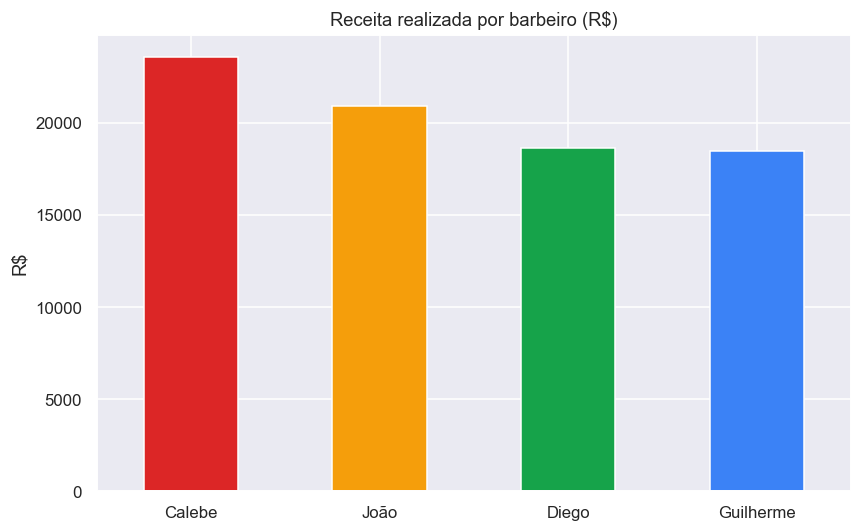

In [3]:
receita = df.groupby('barbeiro')['receita'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
receita.plot(kind='bar', color=PALETTE, ax=ax)
ax.set_title('Receita realizada por barbeiro (R$)')
ax.set_ylabel('R$')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Gráfico de Linhas — Evolução diária

Identifica tendências, sazonalidade e dias-pico.

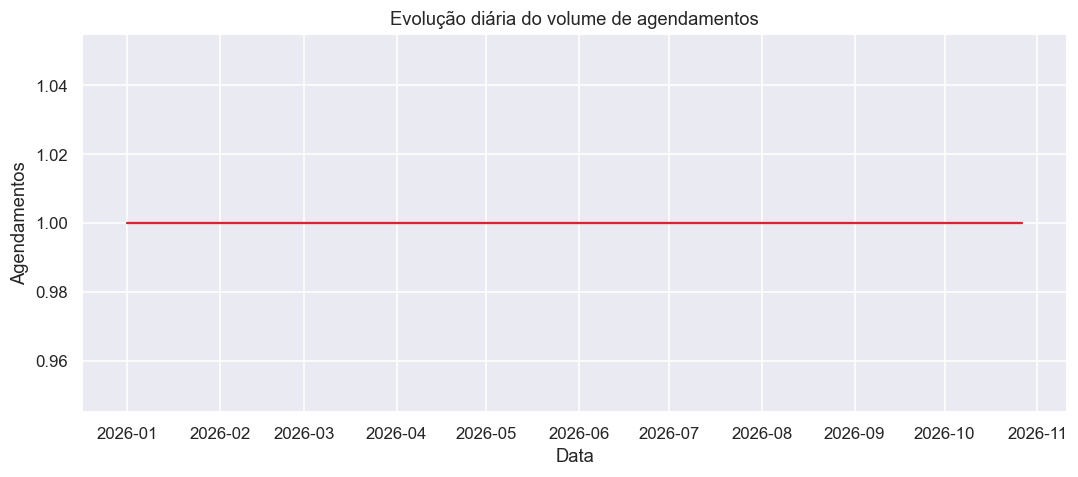

In [4]:
serie = df.groupby(df['data'].dt.date).size()
fig, ax = plt.subplots(figsize=(10, 4.5))
serie.plot(ax=ax, color=PALETTE[0])
ax.set_title('Evolução diária do volume de agendamentos')
ax.set_ylabel('Agendamentos')
ax.set_xlabel('Data')
plt.tight_layout()
plt.show()

## 3. Dispersão — Duração × Preço

Visualiza a relação entre tempo gasto e valor cobrado.

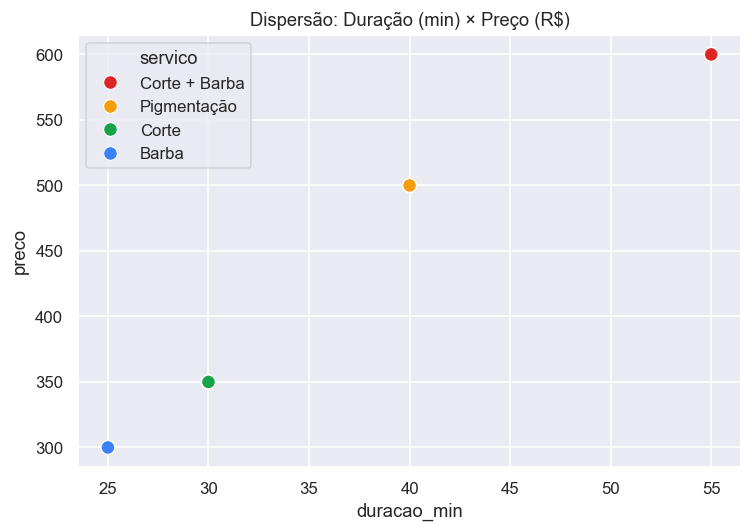

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='duracao_min', y='preco', hue='servico', s=80, ax=ax)
ax.set_title('Dispersão: Duração (min) × Preço (R$)')
plt.tight_layout()
plt.show()

## 4. Histograma — Distribuição de preços

Mostra onde se concentram os preços; permite identificar agrupamentos de serviços.

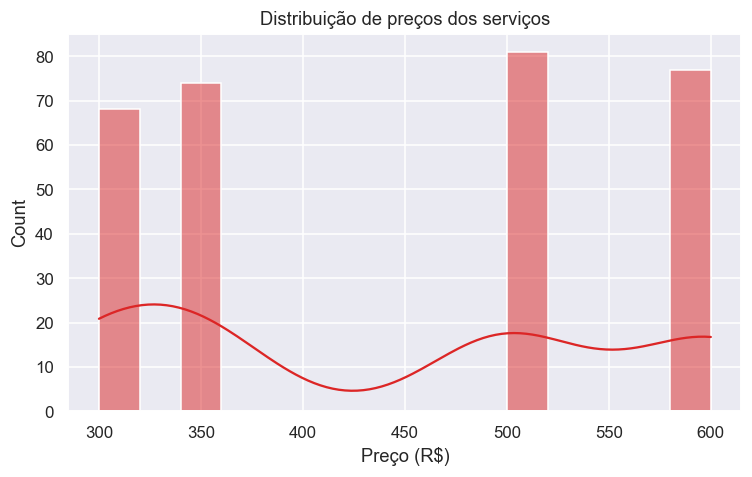

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df['preco'], bins=15, kde=True, color=PALETTE[0], ax=ax)
ax.set_title('Distribuição de preços dos serviços')
ax.set_xlabel('Preço (R$)')
plt.tight_layout()
plt.show()

## 5. Boxplot — Preço por serviço (outliers)

Cada caixa mostra o intervalo interquartil. Pontos fora dos *whiskers* são **outliers** — atendimentos com preço atípico que merecem investigação.

C:\Users\joaof\AppData\Local\Temp\ipykernel_38448\1833148613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='servico', y='preco', palette=PALETTE, ax=ax)
C:\Users\joaof\AppData\Local\Temp\ipykernel_38448\1833148613.py:2: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.boxplot(data=df, x='servico', y='preco', palette=PALETTE, ax=ax)


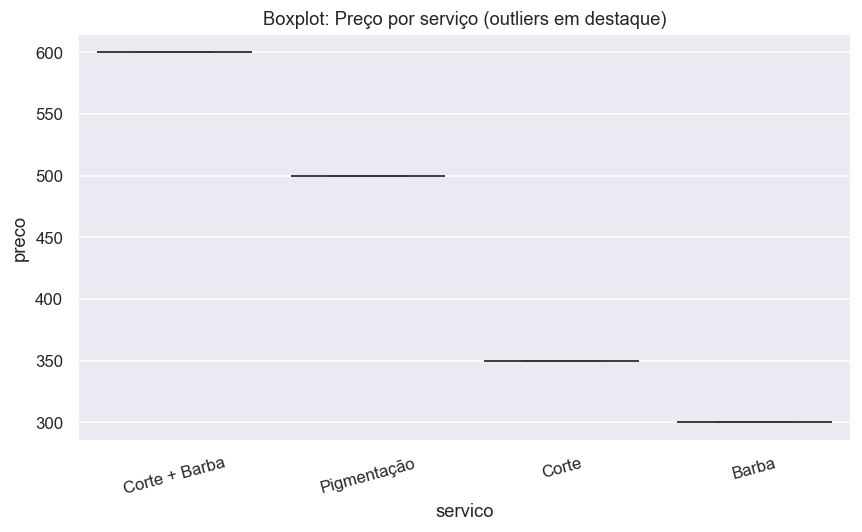

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='servico', y='preco', palette=PALETTE, ax=ax)
ax.set_title('Boxplot: Preço por serviço (outliers em destaque)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Mapa de calor — Correlações de Spearman

Cores quentes (vermelho/verde escuro) indicam correlações fortes. Útil para descobrir relações não óbvias entre variáveis numéricas.

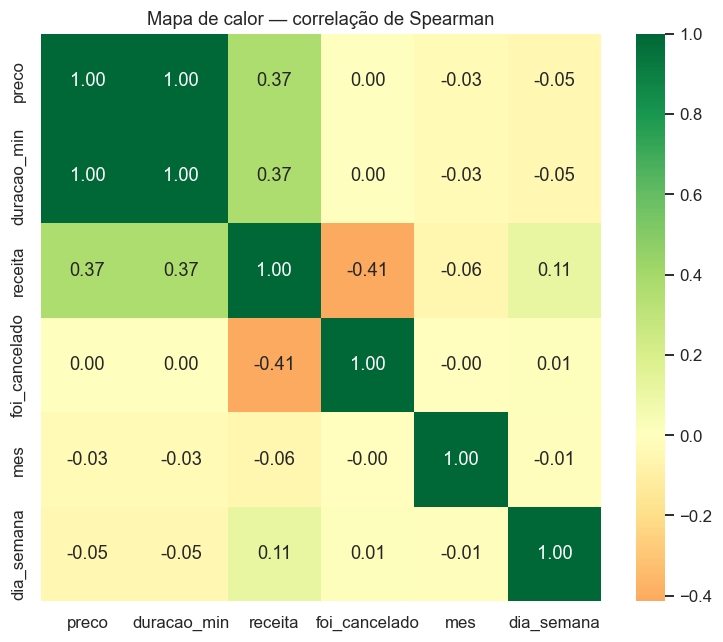

In [8]:
numericas = df[['preco', 'duracao_min', 'receita', 'foi_cancelado', 'mes', 'dia_semana']]
corr = numericas.corr(method='spearman')
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Mapa de calor — correlação de Spearman')
plt.tight_layout()
plt.show()

## 7. Donut (Pizza) — Composição de status dos agendamentos

Mostra a fatia de cada status (`concluido`, `cancelado`, `confirmado`) sobre
o total. **Regra do guia:** usar no máximo 4–5 categorias (temos 3 → ideal).

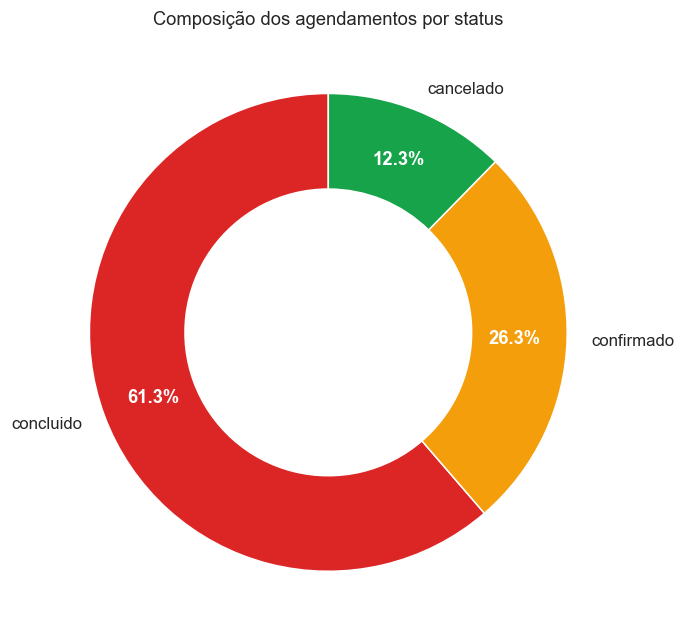

In [9]:
composicao = df['status'].value_counts()

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    composicao.values,
    labels=composicao.index,
    colors=PALETTE[:len(composicao)],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.4, edgecolor='white'),
)
for t in autotexts:
    t.set_color('white')
    t.set_fontweight('bold')

ax.set_title('Composição dos agendamentos por status')
plt.tight_layout()
plt.show()

## 8. Pareto (80/20) — Concentração de receita por serviço

Baseado na **regra de Pareto**: ajuda a provar que 80% da receita vem de
poucos serviços. Eixo esquerdo = receita por serviço (barras); eixo direito
= % acumulado da receita (linha). A linha tracejada em 80% mostra o ponto
de corte clássico.

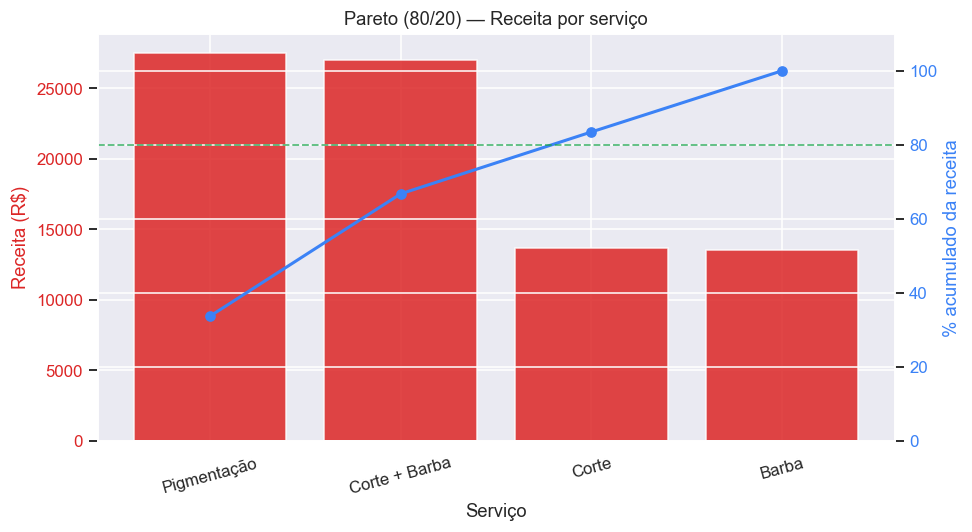


Tabela do Pareto:
               receita  acumulado_pct
servico                              
Pigmentação    27500.0          33.68
Corte + Barba  27000.0          66.75
Corte          13650.0          83.47
Barba          13500.0         100.00


In [10]:
pareto = (df.groupby('servico')['receita'].sum()
            .sort_values(ascending=False)
            .to_frame())
pareto['acumulado_pct'] = pareto['receita'].cumsum() / pareto['receita'].sum() * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(pareto.index, pareto['receita'], color=PALETTE[0], alpha=0.85)
ax1.set_ylabel('Receita (R$)', color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])
ax1.set_xlabel('Serviço')
plt.setp(ax1.get_xticklabels(), rotation=15)

ax2 = ax1.twinx()
ax2.plot(pareto.index, pareto['acumulado_pct'],
         color=PALETTE[3], marker='o', linewidth=2)
ax2.axhline(80, color=PALETTE[2], linestyle='--', linewidth=1.2, alpha=0.7)
ax2.set_ylabel('% acumulado da receita', color=PALETTE[3])
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', labelcolor=PALETTE[3])

plt.title('Pareto (80/20) — Receita por serviço')
plt.tight_layout()
plt.show()

print('\nTabela do Pareto:')
print(pareto.round(2).to_string())

## Conclusão visual

Use estes **8 gráficos** no PDF final para **comprovar visualmente** os números
calculados no notebook anterior. Cada figura responde a uma pergunta de negócio:

| Gráfico | Pergunta de negócio |
|---|---|
| Barras | Quem é o barbeiro mais rentável? |
| Linhas | A demanda está crescendo ou caindo? |
| Dispersão | Serviços mais longos cobram proporcionalmente mais? |
| Histograma | Há concentração de preços baixos (margem apertada)? |
| Boxplot | Existem cancelamentos de serviços muito caros (outliers)? |
| Heatmap | Cancelamento se correlaciona com algum dia da semana? |
| Donut | Qual é a proporção de cancelados vs. concluídos? |
| Pareto | Quais serviços concentram 80% da receita (80/20)? |

> **Combinação estratégica conforme guia oficial (item 2.3):** estes 8 gráficos
> cobrem comparação, tendência, correlação, distribuição, outliers, composição
> e concentração — toda a paleta analítica que a banca espera.